In [16]:
import sys
sys.path.append("../src")

import torch
import matplotlib.pyplot as plt
import random

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from torch.utils.data import DataLoader
from torchvision import transforms

from config import TEST_DIR, CLASSES, IMAGE_SIZE, SEED
from dataset import BrainTumorDataset
from models import BaselineCNN

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = BrainTumorDataset(
    TEST_DIR,
    CLASSES,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

len(test_dataset)

1600

In [4]:
model = BaselineCNN().to(device)

model.load_state_dict(
    torch.load(
        "../models/baseline_cnn.pth",
        map_location=device
    )
)

model.eval()

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [5]:
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [7]:
test_accuracy = (
    sum(p == y for p, y in zip(all_predictions, all_labels))
    / len(all_labels)
)

test_accuracy

np.float64(0.865625)

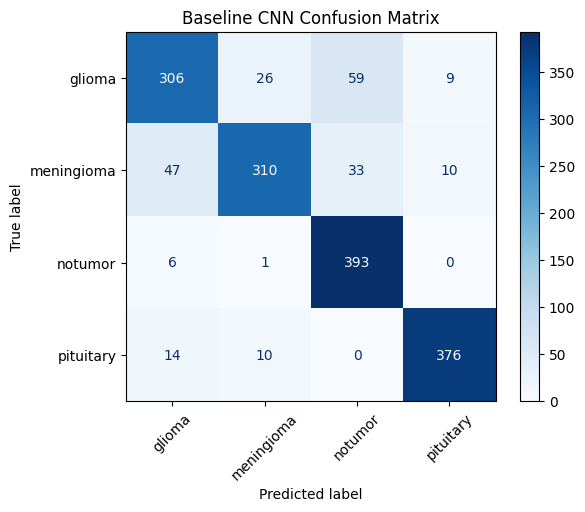

In [8]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Baseline CNN Confusion Matrix")
plt.show()

In [9]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

      glioma       0.82      0.77      0.79       400
  meningioma       0.89      0.78      0.83       400
     notumor       0.81      0.98      0.89       400
   pituitary       0.95      0.94      0.95       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.86      1600
weighted avg       0.87      0.87      0.86      1600



In [10]:
misclassified_indices = [
    i for i, (pred, true) in enumerate(zip(all_predictions, all_labels))
    if pred != true
]

len(misclassified_indices)

215

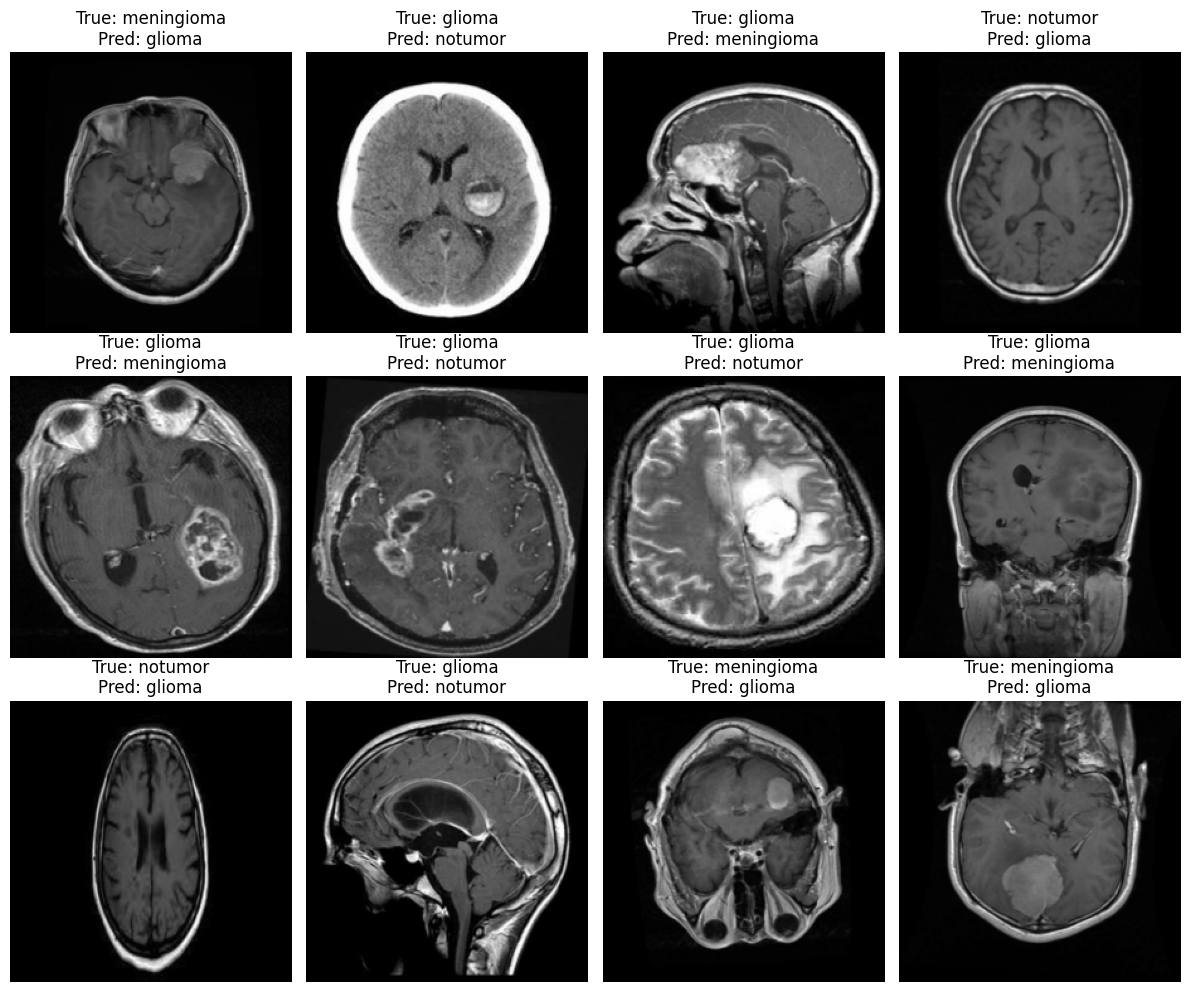

In [17]:
def show_misclassified_examples(dataset, indices, predictions, labels, n=12):
    rng = random.Random(SEED)
    sampled_indices = rng.sample(indices, n)
    
    plt.figure(figsize=(12,10))

    for plot_idx, dataset_idx in enumerate(sampled_indices, start=1):
        image, true_label = dataset[dataset_idx]
        predicted_label = predictions[dataset_idx]

        image = image.squeeze().numpy()

        plt.subplot(3,4, plot_idx)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"True: {CLASSES[true_label]}\nPred: {CLASSES[predicted_label]}"
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_misclassified_examples(
    test_dataset,
    misclassified_indices,
    all_predictions,
    all_labels,
    n=12
)